In [1]:
from thinkdsp import read_wave
from thinkdsp import decorate
filename = '92002__jcveliz__violin-origional.wav'
wave = read_wave(filename)

start = 1.2
duration = 0.6
segment = wave.segment(start, duration)

spectrum = segment.make_spectrum()
spectrum.plot()
decorate(xlabel='Frequency (Hz)')
decorate(ylabel='Amplitude')

spectrum.low_pass(3000)
spectrum.plot(high=10000)
decorate(xlabel='Frequency (Hz)')

FileNotFoundError: [Errno 2] No such file or directory: '92002__jcveliz__violin-origional.wav'

In [ ]:
low_pass_spectrum = spectrum.copy()
low_pass_spectrum.low_pass(3000)
low_pass_spectrum.plot(high=10000)
decorate(xlabel='Frequency (Hz)')
decorate(ylabel='Amplitude')

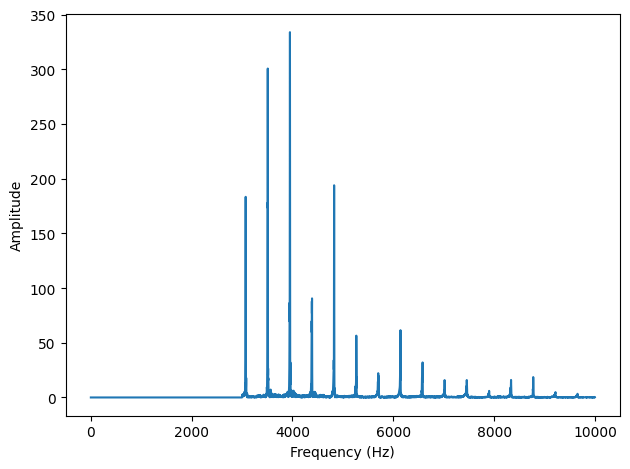

In [40]:
high_pass_spectrum = spectrum.copy()
high_pass_spectrum.high_pass(3000)
high_pass_spectrum.plot(high=10000)
decorate(xlabel='Frequency (Hz)')
decorate(ylabel='Amplitude')

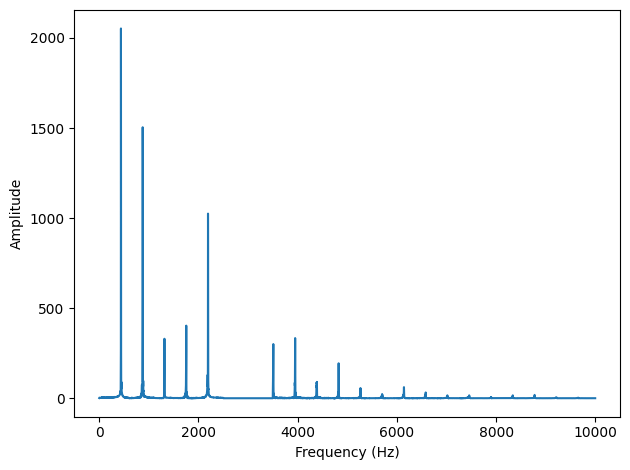

In [42]:
band_stop_spectrum = spectrum.copy()
band_stop_spectrum.band_stop(2500, 3500)
band_stop_spectrum.plot(high=10000)
decorate(xlabel='Frequency (Hz)')
decorate(ylabel='Amplitude')

In [47]:
low_pass_filtered = low_pass_spectrum.make_wave()
low_pass_filtered.make_audio()

In [49]:
high_pass_filtered = high_pass_spectrum.make_wave()
high_pass_filtered.make_audio()

In [51]:
band_stop_filtered = band_stop_spectrum.make_wave()
band_stop_filtered.make_audio()

In [52]:
from thinkdsp import CosSignal, SinSignal

cos_sig = CosSignal(freq=440, amp=1.0, offset=0)
sin_sig = SinSignal(freq=880, amp=0.5, offset=0)

mix = sin_sig + cos_sig

wave = mix.make_wave(duration=0.5, start=0, framerate=11025)

wave.make_audio()

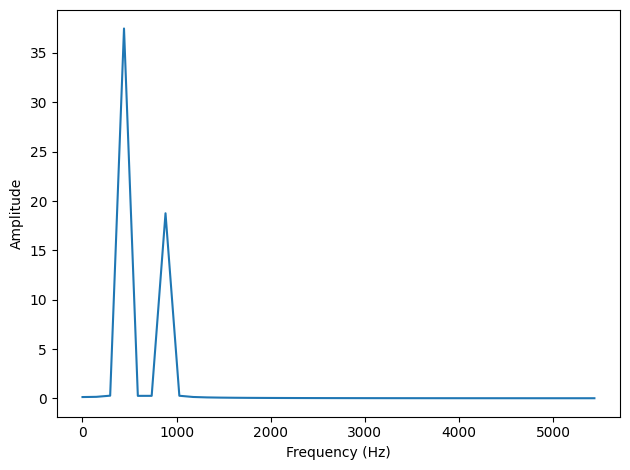

In [57]:
period = mix.period
segment = wave.segment(start=0, duration=period*3)
spectrum = segment.make_spectrum()
spectrum.plot()
decorate(xlabel='Frequency (Hz)')
decorate(ylabel='Amplitude')

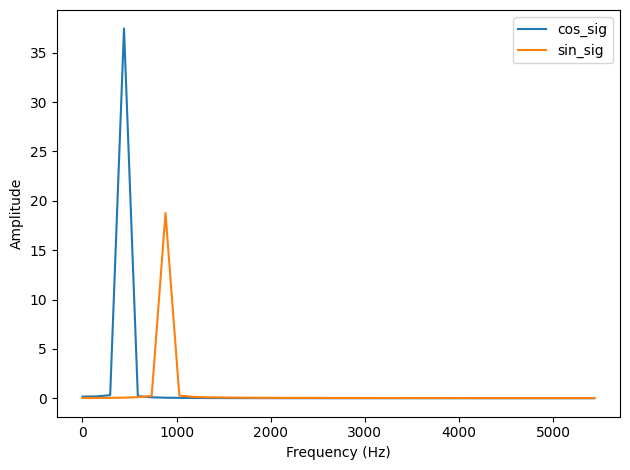

In [60]:
cos_sig_wave = cos_sig.make_wave(duration=0.5, start=0, framerate=11025)
cos_sig_segment = cos_sig_wave.segment(start=0, duration=period*3)
cos_sig_spectrum = cos_sig_segment.make_spectrum()
cos_sig_spectrum.plot(label="cos_sig")

sin_sig_wave = sin_sig.make_wave(duration=0.5, start=0, framerate=11025)
sin_sig_segment = sin_sig_wave.segment(start=0, duration=period*3)
sin_sig_spectrum = sin_sig_segment.make_spectrum()
sin_sig_spectrum.plot(label="sin_sig")

decorate(xlabel='Frequency (Hz)')
decorate(ylabel='Amplitude')
plt.legend()

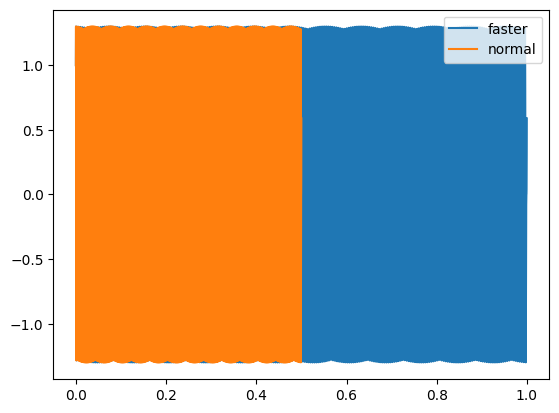

In [88]:
faster_wave = wave.copy()

def stretch(wave, factor):
    wave.ts *= factor
    wave.framerate /= factor

stretch(faster_wave, 2)
faster_wave.plot(label="faster")
wave.plot(label="normal")
plt.legend()